# Reseting parameters

In [ ]:
import matplotlib.pyplot as plt

import finitewave as fw
import numpy as np


model_parameters = {
    "D_model": 0.188,
    "tau_v1_m": 41.857,
    "tau_v2_m": 1150.0,
    "tau_v_p": 1.7,
    "tau_w1_m": 138.69,
    "tau_w2_m": 62.341,
    "tau_w_p": 177.41,
    "tau_fi": 0.045,
    "tau_o1": 410.0,
    "tau_o2": 64.914,
    "tau_so1": 115,
    "tau_so2": 6.5,
    "tau_s1": 11.457,
    "tau_s2": 53.902,
    "tau_si": 7.802,
    "tau_w_inf": 0.050,
    "theta_v": 0.35,
    "theta_w": 0.328,
    "theta_v_m": 0.126,
    "theta_o": 0.00005,
    "u_w_m": 0.055,
    "u_o": 0.0,
    "u_u": 0.9205,
    "u_so": 0.332,
    "u_s": 0.792,
    "k_w_m": 202.66,
    "k_so": 1.386,
    "k_s": 1.226,
    "w_inf_": 1.0
    }

stim_prepacing = fw.StimSingleCell(dt=0.01)
stim_prepacing.add_stim(n_beats=30, cycle_length=1000, duration=1, curr_value=0.5)
stim_prepacing.add_stim(n_beats=30, cycle_length=500, duration=1, curr_value=0.5)

cardiac_model = fw.BuenoOrovio()
cardiac_model.set_parameters(model_parameters)
cardiac_model.prepacing(stim_prepacing)


# create a tissue of size 400x400 with cardiomycytes:
n = 335
tissue = fw.CardiacTissue([n, n], dr=0.25)

# set up stimulation parameters:
stim_sequence = fw.StimSequence()
stim_sequence.add_stim(fw.StimVoltageCoord(time=0, volt_value=1,
                                           x_min=n//2 - 3, x_max=n//2 + 3,
                                           y_min=n//2 - 3, y_max=n//2 + 3))

# create model object and set up parameters:
simulation = fw.CardiacSimulation()
simulation.dt = 0.01
simulation.t_max = 30
simulation.cardiac_tissue = tissue
simulation.stim_sequence = stim_sequence
simulation.cardiac_model = cardiac_model

# run the model:
simulation.run()

# plt.figure()
# plt.imshow(simulation.diffusion_model.weights[0].toarray())
# plt.show()

# show the potential map at the end of calculations:
plt.figure()
plt.imshow(simulation.cardiac_model.output("u"))
plt.colorbar()
plt.show()

# Building new model

In [ ]:
import jax.numpy as jnp
import jax
import finitewave as fw


@jax.jit
def ionic_step(dt, u, v, a, k, eps, mu):
    rhs = - k * u * (u - a) * (u - 1) - u * v
    dv = calc_dv(u, v, a, k, eps, mu)
    v_new = v + dt * dv
    return rhs, v_new

@jax.jit
def calc_dv(u, v, a, k, eps, mu):
    return - (eps  + mu * v) * (v + k * u * (u - a - 1) )


class AlievPanfilovLinear(fw.CardiacModelBase):
    def __init__(self):
        super().__init__()
        self.D_model = 1.0

    def initialize(self, simulation):
        tissue_size = simulation.cardiac_tissue.tissue_indexes.shape
        self.u = jnp.zeros(tissue_size, dtype=jnp.float32)
        self.v = jnp.zeros(tissue_size, dtype=jnp.float32)
        self.a = 0.1
        self.k = 8.0
        self.eps = 0.01
        self.mu = 0.01

    def run(self):
        ionic_step(self.simulation.dt, self.u, self.v, self.a, self.k, self.eps, self.mu)

In [3]:
from types import SimpleNamespace

import finitewave as fw


def get_diffusion_coefficient():
    return {"D_model": 1.0}

def get_variables():
    return {"u": 0.0, "v": 0.0}


def get_parameters():
    return {"a": 0.1, "k": 8., "eps": 0.01, "mu": 0.01}


def ionic_step(dt, u, v, a, k, eps, mu):
    rhs = - k * u * (u - a) * (u - 1) - u * v
    dv = calc_dv(u, v, a, k, eps, mu)
    v_new = v + dt * dv
    return rhs, v_new


def calc_dv(u, v, a, k, eps, mu):
    return - (eps  + mu * v) * (v + k * u * (u - a - 1) )


ops = SimpleNamespace(
    get_diffusion_coefficient=get_diffusion_coefficient,
    get_variables=get_variables,
    get_parameters=get_parameters,
    ionic_step=ionic_step,
    calc_dv=calc_dv
)

class AlievPanfilovLinear(fw.CardiacModel):
    finitewave_model = False
    def __init__(self, memory_save=False):
        super().__init__(memory_save=memory_save)
        self.ops = ops
        self.initialize_variables_and_parameters()


Running AlievPanfilovLinear on [100, 5] Grid: 100%|██████████| 20000/20000 [00:00<00:00, 32037.83it/s]


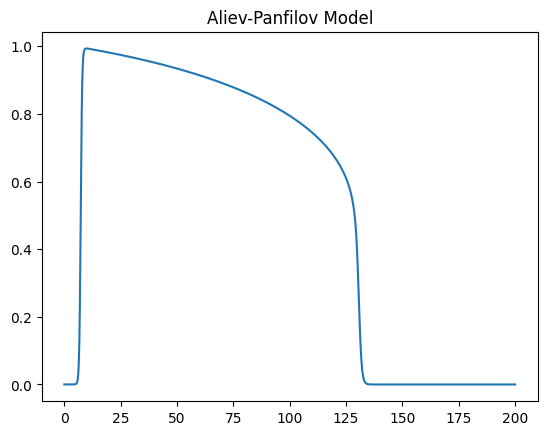

In [4]:
import matplotlib.pyplot as plt


n = 100
m = 5
tissue = fw.CardiacTissue([n, m], dr=0.25)

# set up stimulation parameters:
stim_sequence = fw.StimSequence()
stim_sequence.add_stim(fw.StimVoltageCoord(time=0, volt_value=1,
                                            x_min=0, x_max=5,
                                            y_min=0, y_max=m))

action_pot_tracker = fw.ActionPotentialTracker()
action_pot_tracker.node_inds = [[n//2, m//2]]
action_pot_tracker.step = 1

tracker_sequence = fw.TrackerSequence()
tracker_sequence.add_tracker(action_pot_tracker)

# create model object and set up parameters:
simulation = fw.CardiacSimulation(dt=0.01, t_max=200)
simulation.cardiac_model = AlievPanfilovLinear()
simulation.cardiac_tissue = tissue
simulation.stim_sequence = stim_sequence
simulation.tracker_sequence = tracker_sequence

# run the model:
simulation.run()

times = action_pot_tracker.tracking_times
act_pot = action_pot_tracker.output

plt.figure()
plt.plot(times, act_pot)
plt.title('Aliev-Panfilov Model')
plt.show()

In [4]:
import numpy as np
import jax.numpy as jnp
import mlx.core as mx


class A:
    def __init__(self):
        self.a = jnp.array([1])
        self.b = mx.array([2])
        self.c = 3
        self.state_vars = ["a", "b", "c"]

    def __getattr__(self, name):
        print(f"Accessing attribute: {name}")
        if name in self.state_vars:
            return np.asarray(self.__dict__[name])
        raise AttributeError(f"{type(self).__name__!r} has no attribute {name!r}")


a = A()
a.d = 4
print(a.d)

4


In [5]:
import numpy as np


def is_array(x):
    return hasattr(x, "__array_namespace__")

a = np.array([[[1]]])

not is_array(a) 

False